In [1]:
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u

SED_KEV_TO_ERG = u.keV.to(u.erg)
KEV_TO_MEV = u.keV.to(u.MeV)
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter
from threeML.minimizer.minimization import CannotComputeCovariance

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()

from scipy.integrate import quad

import matplotlib.ticker as mticker

from pathlib import Path

import os

%matplotlib inline


16:02:48 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=971173;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=614610;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=414916;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=541762;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=443469;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=78588;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

16:02:49 INFO      Starting 3ML!                                                                     ]8;id=27459;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=624133;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=540683;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=88467;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=74296;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=727750;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=742673;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=432408;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=660545;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=70316;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=210430;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=565422;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=542570;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=78072;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
data_path = Path("/Users/parshadkp/Software/COSI_Data/")

In [3]:
from cosipy.event_selection import GoodTimeInterval
from agn_cosi_fit_utils import draw_energy_hist_mev, open_spacecraft_history, scale_spacecraft_livetime

orientation_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
source_coord = SkyCoord(l=172.104, b=-51.934, frame="galactic", unit="deg")
fov_cut = 60 * u.deg

full_sc_orientation = open_spacecraft_history(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    full_sc_orientation,
    fov_cut,
    earth_occ=False,
)
sc_orientation = full_sc_orientation.apply_gti(source_gti)

print(f"NGC 1068 FOV cut: {fov_cut.to_value(u.deg):.0f} deg")
print(f"Selected livetime: {sc_orientation.cumulative_livetime().to_value(u.s):,.1f} s")

NGC 1068 FOV cut: 60 deg
Selected livetime: 2,546,115.0 s


In [4]:
dr = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"

In [5]:
cutoff_keV = 3750
multiplier_1068 = 8
exposure_1068 = multiplier_1068 * 3

# Scale count histograms and response livetime together; keep source flux intrinsic.
sc_orientation = scale_spacecraft_livetime(sc_orientation, multiplier_1068)


# Source Model Plots

## Cutoff Power Law (Thermal)

#### NGC 1068 (100 keV)


In [6]:
K_inj = 3.1e-1 * (1e-3) / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = float(cutoff_keV) * u.keV
index_inj = -1.85

spectrum_inj_1068 = Cutoff_powerlaw()

spectrum_inj_1068.K.value = K_inj.value
spectrum_inj_1068.piv.value = piv_inj.value
spectrum_inj_1068.xc.value = xc_inj.value
spectrum_inj_1068.index.value = index_inj

spectrum_inj_1068.K.unit = K_inj.unit
spectrum_inj_1068.piv.unit = piv_inj.unit
spectrum_inj_1068.xc.unit = xc_inj.unit


## Injected cutoff-model diagnostics


The injected reference contains one cutoff power law and no non-thermal tail.


In [7]:
print("Injected photon flux at 200 keV:", spectrum_inj_1068.evaluate_at(200.0))

photon_flux, photon_flux_error = quad(
    spectrum_inj_1068.evaluate_at,
    200.0,
    5000.0,
)
energy_flux_keV, energy_flux_keV_error = quad(
    lambda energy: energy * spectrum_inj_1068.evaluate_at(energy),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_keV * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_error = (energy_flux_keV_error * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("Integrated photon flux (200-5000 keV):", photon_flux)
print("Integrated photon-flux error:", photon_flux_error)
print("Integrated energy flux (200-5000 keV):", energy_flux)
print("Integrated energy-flux error:", energy_flux_error)


Injected photon flux at 200 keV: 1.626648921169095e-08
Integrated photon flux (200-5000 keV): 3.152682460249617e-06
Integrated photon-flux error: 3.289661757450213e-11
Integrated energy flux (200-5000 keV): 3.0934821785033025e-12 erg / (s cm2)
Integrated energy-flux error: 3.493965279238704e-19 erg / (s cm2)


The fitted and injected spectra are plotted after the likelihood fit.

# Spectral Fitting

This notebook performs one COSI-only cutoff-power-law fit.


In [8]:
# source_file = Path(
#     "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/"
#     "NGC1068_ec_128_-2.1_DC4_COSI_cpl_60_fovCut.hdf5"
# )

source_file = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/"
    "NGC1068_ec_128_-1.85_normTH_0.35_DC4_COSI_cpl_nth_60_fovCut.hdf5"
)

background_file = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files/Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC1068_60deg_fov_cut.hdf5"
)

for required_file in (source_file, background_file):
    if not required_file.exists():
        raise FileNotFoundError(required_file)

ngc1068_source_hist = Histogram.open(source_file) * multiplier_1068
bkg = Histogram.open(background_file) * multiplier_1068

# Collapse the background time axis and match the source histogram metadata.
bkg = bkg.project("Em", "Phi", "PsiChi")
ngc1068_source_hist.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
ngc1068_source_hist = ngc1068_source_hist.to(
    unit=bkg.unit,
    update=False,
)

ngc1068_data_hist = ngc1068_source_hist + bkg

print(f"Loaded source: {source_file.name}")
print(f"Loaded background: {background_file.name}")


Loaded source: NGC1068_ec_128_-1.85_normTH_0.35_DC4_COSI_cpl_nth_60_fovCut.hdf5
Loaded background: Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC1068_60deg_fov_cut.hdf5


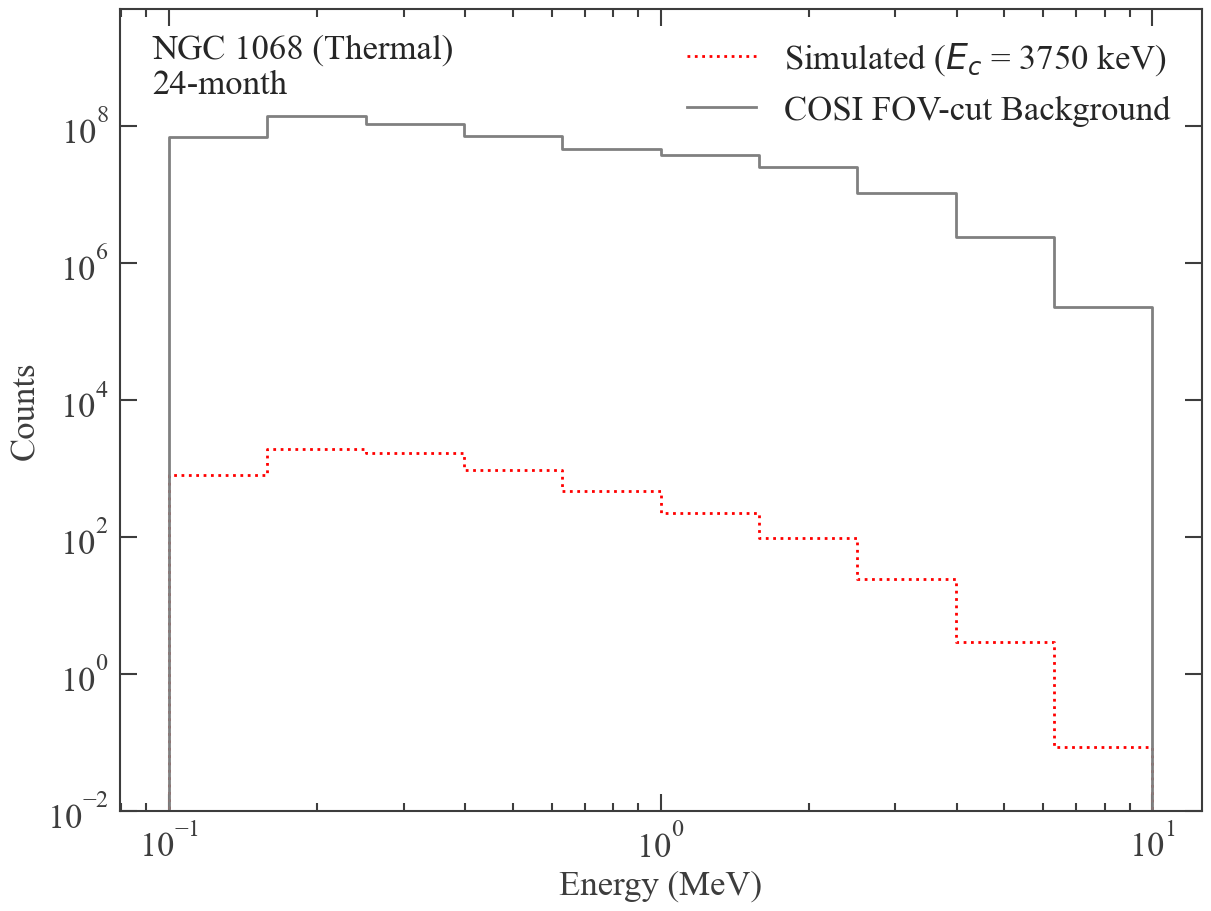

In [9]:
FONT_SIZE = 25
plt.rcParams['agg.path.chunksize'] = 10000
plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550',
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top=True, pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top=True, pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right=True, pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right=True, pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

draw_energy_hist_mev(ngc1068_source_hist, ax,
    label=fr"Simulated ($E_c$ = {cutoff_keV} keV)",
    color="red",
    linestyle="dotted",
)
draw_energy_hist_mev(bkg, ax, label="COSI FOV-cut Background", color="grey")

ax.text(
    0.03,
    0.97,
    f"NGC 1068 (Thermal)\n{exposure_1068}-month",
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=FONT_SIZE,
    fontweight='550',
)

ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e-2, 5e9)
# ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1, 5]))
# ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=FONT_SIZE, loc='upper right', frameon=False)

save_path = (
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    f"Papers/AGN_Corona_EC_Overleaf/Plots/NGC1068_Cpl_Counts_{cutoff_keV}_{exposure_1068}Months.pdf"
)
# plt.savefig(save_path)


# COSI likelihood setup

## Perform the single cutoff fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [9]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter

bkg_par = Parameter(
    "background_cosi",
    1,
    min_value=0,
    max_value=100,
    delta=0.05,
    desc="Background parameter for the NGC 1068 COSI fit",
)

cosi = COSIPlugin(
    "cosi",
    dr=dr,
    data=ngc1068_data_hist.project('Em', 'Phi', 'PsiChi'),
    bkg=bkg.project('Em', 'Phi', 'PsiChi'),
    sc_orientation=sc_orientation,
    nuisance_param=bkg_par,
    earth_occ=True,
)


### Cutoff power-law model

In [10]:
l = 172.104
b = -51.934

K = 3e-4 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
xc = float(cutoff_keV) * u.keV
index = -1.85

spectrum_cpl = Cutoff_powerlaw()
spectrum_cpl.K.value = K.value
spectrum_cpl.piv.value = piv.value
spectrum_cpl.xc.value = xc.value
spectrum_cpl.index.value = index
# spectrum_cpl.index.fix = False

spectrum_cpl.K.min_value = 1e-6
spectrum_cpl.K.max_value = 1e-2
spectrum_cpl.xc.min_value = 10
spectrum_cpl.xc.max_value = 5000
spectrum_cpl.index.min_value = -3
spectrum_cpl.index.max_value = 1

spectrum_cpl.K.unit = K.unit
spectrum_cpl.piv.unit = piv.unit
spectrum_cpl.xc.unit = xc.unit

ngc1068 = PointSource(
    "NGC1068",
    l=l,
    b=b,
    spectral_shape=spectrum_cpl,
)


Only one NGC 1068 cutoff model is fitted in this notebook.


## Single thermal model

In [11]:
model = Model(ngc1068)
cosi.set_model(model)


### COSI-only data list

The active fit below uses COSI only.


### Run the fit

In [12]:
# COSI-only fit
plugins = DataList(cosi)


In [16]:
like = JointLikelihood(model, plugins, verbose=False)
result = like.fit()


16:04:26 INFO      set the minimizer to minuit                                             ]8;id=152013;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=700009;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Best fit values:

,result,unit
parameter,,
NGC1068.spectrum.main.Cutoff_powerlaw.K,0.00032 -0.00032 +5,1 / (keV s cm2)
NGC1068.spectrum.main.Cutoff_powerlaw.index,-1.8 +/- 2.5,
NGC1068.spectrum.main.Cutoff_powerlaw.xc,(0.39 -0.28 +1.0) x 10^4,keV
background_cosi,(2.48983 +/- 0.00007) x 10,Hz


Correlation matrix:

1.00,-1.00,-0.71,-0.78
-1.00,1.00,0.71,0.78
-0.71,0.71,1.00,0.55
-0.78,0.78,0.55,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-3783588844.2536497
total,-3783588844.2536497


Values of statistical measures:

,statistical measures
AIC,-7567177680.507126
BIC,-7567177639.11701


In [17]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter


def make_null_likelihood(data_hist):
    bkg_par_null = Parameter(
        "background_cosi_null",
        1,
        min_value=0,
        max_value=5,
        delta=0.05,
        desc="Background parameter for the NGC 1068 null fit",
    )
    cosi_null = COSIPlugin(
        "cosi_null",
        dr=dr,
        data=data_hist.project('Em', 'Phi', 'PsiChi'),
        bkg=bkg.project('Em', 'Phi', 'PsiChi'),
        sc_orientation=sc_orientation,
        nuisance_param=bkg_par_null,
        earth_occ=True,
    )

    spectrum_null = Powerlaw()
    spectrum_null.K.value = 1e-30
    spectrum_null.index.value = 1
    spectrum_null.K.fix = True
    spectrum_null.index.fix = True

    source_null = PointSource(
        "NGC1068_null",
        l=l,
        b=b,
        spectral_shape=spectrum_null,
    )
    model_null = Model(source_null)
    cosi_null.set_model(model_null)

    like_null = JointLikelihood(model_null, DataList(cosi_null), verbose=False)
    like_null.fit()
    return like_null


def total_fit_statistic(joint_likelihood):
    statistic = joint_likelihood.results.get_statistic_frame()["-log(likelihood)"]
    if "total" in statistic.index:
        return float(statistic.loc["total"])
    return float(statistic.sum())


like_null = make_null_likelihood(ngc1068_data_hist)
fit_statistic = total_fit_statistic(like)
null_statistic = total_fit_statistic(like_null)
TS = max(0.0, 2.0 * (null_statistic - fit_statistic))

print("Source -log(likelihood):", fit_statistic)
print("Null -log(likelihood):", null_statistic)
print("TS value:", TS)
print("NGC 1068 significance:", np.sqrt(TS))


16:04:29 INFO      set the minimizer to minuit                                             ]8;id=14843;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=126204;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Best fit values:

,result,unit
parameter,,
background_cosi_null,(2.48986 +/- 0.00011) x 10,Hz


Correlation matrix:

1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_null,-3783588840.3956704
total,-3783588840.3956704


Values of statistical measures:

,statistical measures
AIC,-7567177678.791324
BIC,-7567177668.4437685


Source -log(likelihood): -3783588844.2536497
Null -log(likelihood): -3783588840.3956704
TS value: 7.715958595275879
NGC 1068 significance: 2.7777614359904774


In [18]:
results = like.results
results_sed = results
data_sed_hist = cosi._data.copy()
bkg_sed_hist = cosi._bkg_hist.copy()

print(results.display())

parameters = {
    parameter.name: results.get_variates(parameter.path)
    for parameter in results.optimized_model["NGC1068"].parameters.values()
    if parameter.free
}
results_err = results.propagate(
    results.optimized_model["NGC1068"].spectrum.main.shape.evaluate_at,
    **parameters,
)


Best fit values:

,result,unit
parameter,,
NGC1068.spectrum.main.Cutoff_powerlaw.K,0.00032 -0.00032 +5,1 / (keV s cm2)
NGC1068.spectrum.main.Cutoff_powerlaw.index,-1.8 +/- 2.5,
NGC1068.spectrum.main.Cutoff_powerlaw.xc,(0.39 -0.28 +1.0) x 10^4,keV
background_cosi,(2.48983 +/- 0.00007) x 10,Hz


Correlation matrix:

1.00,-1.00,-0.71,-0.78
-1.00,1.00,0.71,0.78
-0.71,0.71,1.00,0.55
-0.78,0.78,0.55,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-3783588844.2536497
total,-3783588844.2536497


Values of statistical measures:

,statistical measures
AIC,-7567177680.507126
BIC,-7567177639.11701


None


## Global-fit plot

In [19]:
energy = np.geomspace(100 * u.keV, 10 * u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for index, energy_value in enumerate(energy):
    flux = results_err(energy_value)
    flux_median[index] = flux.median
    flux_lo[index], flux_hi[index] = flux.equal_tail_interval(cl=0.68)
    flux_inj[index] = spectrum_inj_1068.evaluate_at(energy_value)

binned_energy_edges = ngc1068_source_hist.axes['Em'].edges.value
binned_energy = np.array([
    0.5 * (lower + upper)
    for lower, upper in zip(binned_energy_edges[:-1], binned_energy_edges[1:])
])
bin_sizes = np.diff(binned_energy_edges)

expectation = cosi._expected_counts['NGC1068']


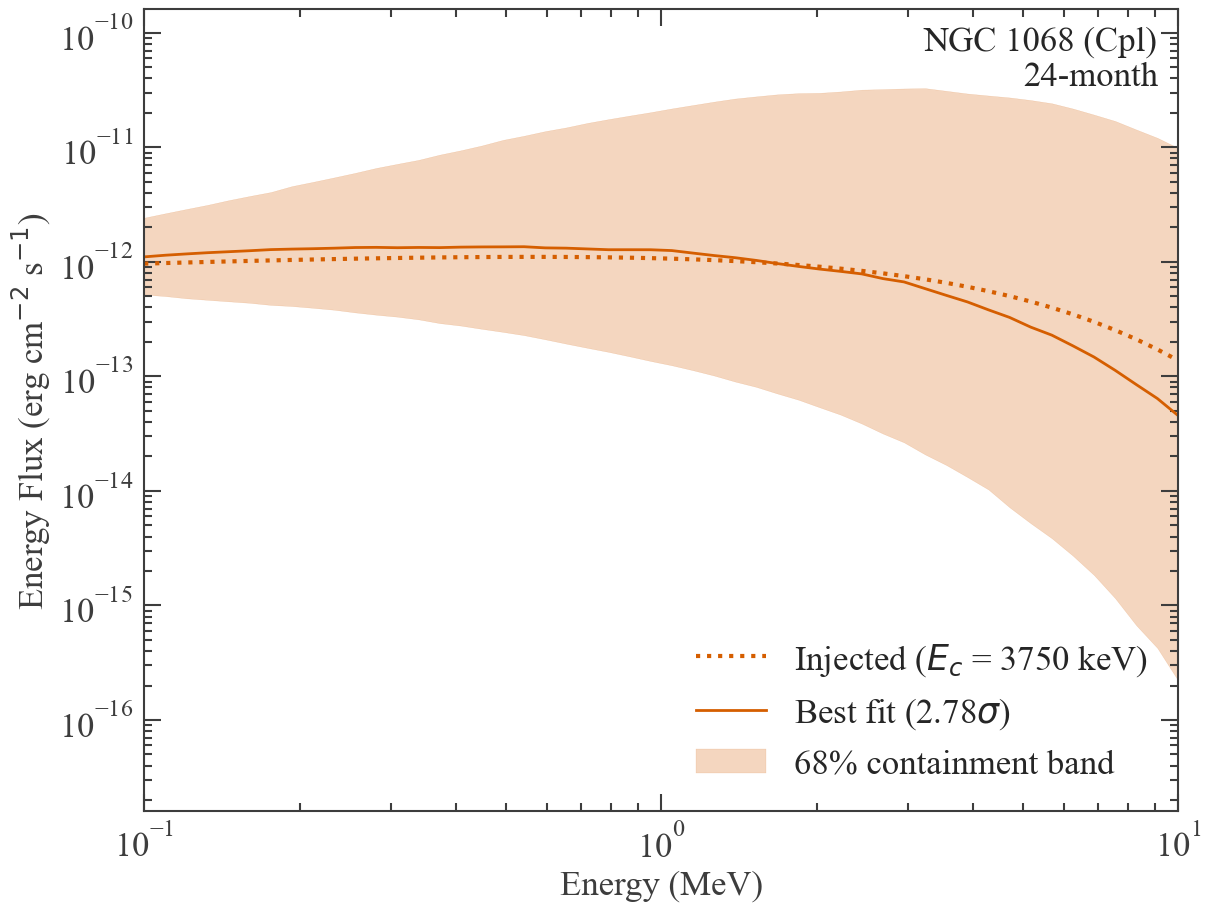

In [21]:
FONT_SIZE = 25
plt.rcParams['agg.path.chunksize'] = 10000
plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550',
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top=True, pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top=True, pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right=True, pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right=True, pad=8)
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

sigma = np.sqrt(TS)
color = '#D55E00'

ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy**2 * flux_inj,
    color=color,
    ls=':',
    lw=3,
    label=fr"Injected ($E_c$ = {cutoff_keV} keV)",
)
ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy**2 * flux_median,
    color=color,
    lw=2,
    label=fr"Best fit ({sigma:.2f}$\sigma$)",
)
ax.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy**2 * flux_lo,
    SED_KEV_TO_ERG * energy**2 * flux_hi,
    alpha=0.25,
    color=color,
    label="68% containment band",
)

ax.text(
    0.98,
    0.98,
    f"NGC 1068 (Cpl)\n{exposure_1068}-month",
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=FONT_SIZE,
    fontweight='550',
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim((100) * KEV_TO_MEV, (10000) * KEV_TO_MEV)
ax.set_ylim(1e-8 * SED_KEV_TO_ERG, 1e-1 * SED_KEV_TO_ERG)
# ax.xaxis.set_major_locator(mticker.FixedLocator([0.1, 5, 10]))
# ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.1", "5", "10"]))
ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
ax.set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
ax.legend(fontsize=FONT_SIZE, loc='lower right', frameon=False)

save_path = (
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    f"Papers/AGN_Corona_EC/Plots/NGC1068_ThModel_TH_Fit_{cutoff_keV}_{exposure_1068}Months.pdf"
)
# plt.savefig(save_path)


## Thermal SED (COSI)

This extracts bin-by-bin COSI SED points from the global thermal fit. In every bin the photon index and cutoff are frozen to the global-fit values so the per-bin fit is driven by the source normalization.


In [24]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter
def _iter_model_sources(model):
    return [
        (name, child)
        for name, child in getattr(model, '_children', {}).items()
        if hasattr(child, 'spectrum')
    ]


def _find_shape_by_class(shape, shape_name):
    if shape is None:
        return None
    if shape.__class__.__name__ == shape_name:
        return shape

    for child_shape in getattr(shape, 'functions', []):
        match = _find_shape_by_class(child_shape, shape_name)
        if match is not None:
            return match

    return None


def _get_source_spectral_shape(source, shape_name='Cutoff_powerlaw'):
    main_component = source.spectrum.main

    for attr in (shape_name, 'shape', 'composite'):
        candidate = getattr(main_component, attr, None)
        match = _find_shape_by_class(candidate, shape_name)
        if match is not None:
            return match

    return None


def _resolve_source_name(model, source_name=None, shape_name='Cutoff_powerlaw'):
    sources = _iter_model_sources(model)

    if source_name is not None:
        source_names = [name for name, _ in sources]
        if source_name not in source_names:
            raise ValueError(f'Source {source_name!r} is not in optimized model. Available sources: {source_names}.')

        source = model[source_name]
        if _get_source_spectral_shape(source, shape_name=shape_name) is None:
            raise ValueError(f'Source {source_name!r} does not contain a {shape_name} shape.')

        return source_name

    source_names = [
        name
        for name, source in sources
        if _get_source_spectral_shape(source, shape_name=shape_name) is not None
    ]

    if len(source_names) != 1:
        raise ValueError(
            f'Expected one source with a {shape_name} shape, found {source_names}. '
            'Pass source_name to select the SED target explicitly.'
        )

    return source_names[0]


def _get_cutoff_powerlaw_shape(global_results, source_name=None):
    optimized_model = global_results.optimized_model
    source_name = _resolve_source_name(optimized_model, source_name=source_name)

    return _get_source_spectral_shape(optimized_model[source_name]), source_name


def build_thermal_sed_model(global_results, freeze_cutoff=True, source_name=None, freeze_non_target_parameters=True):
    from astromodels import clone_model

    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results, source_name=source_name)
    sed_model = clone_model(global_results.optimized_model)
    fit_shape = _get_source_spectral_shape(sed_model[source_name])

    if freeze_non_target_parameters:
        for parameter in sed_model.parameters.values():
            parameter.fix = True

    fit_shape.K.value = best_fit_shape.K.value
    fit_shape.K.min_value = max(best_fit_shape.K.value * 1e-3, 1e-12)
    fit_shape.K.max_value = best_fit_shape.K.value * 1e3
    fit_shape.K.fix = False
    fit_shape.index.value = best_fit_shape.index.value
    fit_shape.index.fix = True
    fit_shape.xc.value = best_fit_shape.xc.value
    fit_shape.xc.fix = freeze_cutoff

    return sed_model


def _hist_sum(hist):
    contents = hist.contents
    if hasattr(contents, 'todense'):
        contents = contents.todense()
    if hasattr(contents, 'value'):
        contents = contents.value
    return float(np.asarray(contents).sum())


def _evaluate_model_photon_flux(model, energy):
    photon_flux = 0.0

    for _, source in _iter_model_sources(model):
        photon_flux += float(source.spectrum.main.shape.evaluate_at(energy))

    return photon_flux


def _with_target_k_value(model, source_name, k_value, evaluator):
    target_shape = _get_source_spectral_shape(model[source_name])
    original_k = target_shape.K.value
    target_shape.K.value = float(k_value)

    try:
        return evaluator()
    finally:
        target_shape.K.value = original_k


def _integrate_model_energy_flux(model, source_name, k_value, e_min, e_max, n_points=256):
    energy_grid = np.geomspace(e_min, e_max, n_points)

    def evaluator():
        return np.asarray([_evaluate_model_photon_flux(model, energy) for energy in energy_grid])

    photon_flux = _with_target_k_value(model, source_name, k_value, evaluator)
    trapezoid = getattr(np, 'trapezoid', None)
    if trapezoid is None:
        trapezoid = np.trapz
    return float(trapezoid(energy_grid * photon_flux, energy_grid))


def _evaluate_model_sed_flux(model, source_name, k_value, energy):
    return _with_target_k_value(
        model,
        source_name,
        k_value,
        lambda: float(energy**2 * _evaluate_model_photon_flux(model, energy)),
    )


def _extract_profile_error(errors, suffix):
    if hasattr(errors, 'index'):
        for parameter_path in errors.index:
            if str(parameter_path).endswith(suffix):
                row = errors.loc[parameter_path]
                return float(row['negative_error']), float(row['positive_error'])
        return None

    for parameter_path, interval in errors.items():
        if str(parameter_path).endswith(suffix):
            return interval
    return None


def _get_global_background_rate(global_results):
    results_frame = global_results.get_data_frame()
    background_paths = [
        parameter_path
        for parameter_path in results_frame.index
        if 'background_' in str(parameter_path) or 'total_bkg' in str(parameter_path)
    ]

    if len(background_paths) != 1:
        raise ValueError(
            'Expected exactly one fitted background-rate parameter, '
            f'found {list(map(str, background_paths))}.'
        )

    return float(results_frame.loc[background_paths[0], 'value'])


def _run_joint_likelihood_fit(joint_likelihood):
    fit_status = 'covariance'
    try:
        joint_likelihood.fit(quiet=True)
    except Exception as exc:
        fit_status = f'no-covariance fallback ({type(exc).__name__})'
        joint_likelihood.fit(quiet=True, compute_covariance=False)
    return fit_status


def _get_joint_likelihood_statistic(joint_likelihood):
    statistic_frame = joint_likelihood.results.get_statistic_frame()

    if '-log(likelihood)' in statistic_frame.columns:
        statistic_column = statistic_frame['-log(likelihood)']
    else:
        numeric_frame = statistic_frame.select_dtypes(include=[np.number])
        if numeric_frame.empty:
            raise ValueError(f'No numeric statistic columns found in {list(statistic_frame.columns)}.')
        statistic_column = numeric_frame.iloc[:, 0]

    if 'total' in statistic_column.index:
        return float(statistic_column.loc['total'])

    return float(statistic_column.sum())


def _ts_to_sigma(ts_value):
    if not np.isfinite(ts_value) or ts_value <= 0:
        return 0.0

    return float(np.sqrt(ts_value))


def _build_null_sed_model(
    global_results,
    source_name,
    freeze_cutoff=True,
    freeze_non_target_parameters=True,
    null_k_value=1e-30,
):
    null_model = build_thermal_sed_model(
        global_results,
        freeze_cutoff=freeze_cutoff,
        source_name=source_name,
        freeze_non_target_parameters=freeze_non_target_parameters,
    )
    null_shape = _get_source_spectral_shape(null_model[source_name])
    null_k_value = max(float(null_k_value), np.finfo(float).tiny)
    null_k_min = max(null_k_value * 0.1, np.finfo(float).tiny)
    null_shape.K.min_value = min(float(null_shape.K.min_value or null_k_min), null_k_min)
    null_shape.K.value = null_k_value
    null_shape.K.fix = True

    return null_model


def _make_minuit_with_ftol(minuit_ftol):
    if minuit_ftol is None:
        return None

    minuit = LocalMinimization('minuit')
    minuit.setup(ftol=float(minuit_ftol))

    return minuit


def _hits_lower_bound(value, lower_bound):
    if lower_bound is None or not np.isfinite(lower_bound):
        return False

    atol = max(1e-18, abs(float(lower_bound)) * 1e-6)
    return bool(np.isclose(float(value), float(lower_bound), rtol=1e-3, atol=atol))


def _interpolate_profile_crossing(x1, y1, x2, y2, target):
    if np.isclose(y1, y2):
        return float(0.5 * (x1 + x2))

    fraction = float((target - y1) / (y2 - y1))
    fraction = float(np.clip(fraction, 0.0, 1.0))

    if x1 > 0 and x2 > 0:
        return float(np.exp(np.log(x1) + fraction * (np.log(x2) - np.log(x1))))

    return float(x1 + fraction * (x2 - x1))


def _find_profile_crossing(x_values, delta_ts, threshold, side):
    if len(x_values) == 0:
        return None

    minimum_index = int(np.nanargmin(delta_ts))

    if side == 'left':
        for index in range(minimum_index - 1, -1, -1):
            y1 = float(delta_ts[index])
            y2 = float(delta_ts[index + 1])
            if np.isnan(y1) or np.isnan(y2):
                continue
            if np.isclose(y1, threshold):
                return float(x_values[index])
            if (y1 - threshold) * (y2 - threshold) <= 0:
                return _interpolate_profile_crossing(
                    float(x_values[index]),
                    y1,
                    float(x_values[index + 1]),
                    y2,
                    threshold,
                )
        return None

    for index in range(minimum_index, len(x_values) - 1):
        y1 = float(delta_ts[index])
        y2 = float(delta_ts[index + 1])
        if np.isnan(y1) or np.isnan(y2):
            continue
        if np.isclose(y2, threshold):
            return float(x_values[index + 1])
        if (y1 - threshold) * (y2 - threshold) <= 0:
            return _interpolate_profile_crossing(
                float(x_values[index]),
                y1,
                float(x_values[index + 1]),
                y2,
                threshold,
            )

    return None


def _manual_k_profile_interval(
    joint_likelihood,
    parameter_path,
    center_value,
    lower_bound,
    upper_bound,
    n_steps=61,
    target_delta_ts=1.0,
    max_expansions=12,
    scan_expand_factor=1e2,
):
    if center_value <= 0:
        raise ValueError('Manual K profiling requires a positive best-fit normalization.')

    tiny_positive = float(np.finfo(float).tiny)
    scan_min = max(float(lower_bound), tiny_positive)
    scan_max = float(upper_bound) if np.isfinite(upper_bound) else float(center_value) * 1e6

    if not np.isfinite(scan_max) or scan_max <= scan_min:
        raise ValueError('Invalid K scan bounds for manual profiling.')

    import matplotlib.pyplot as plt

    left_crossing = None
    right_crossing = None

    for _ in range(max_expansions + 1):
        x_values, _, profile_values, profile_figure = joint_likelihood.get_contours(
            parameter_path,
            param_1_minimum=float(scan_min),
            param_1_maximum=float(scan_max),
            param_1_n_steps=int(n_steps),
            progress=False,
            log=(True,),
        )
        plt.close(profile_figure)

        x_values = np.asarray(x_values, dtype=float)
        profile_values = np.asarray(profile_values, dtype=float)
        delta_ts = 2.0 * (profile_values - np.nanmin(profile_values))
        minimum_index = int(np.nanargmin(delta_ts))

        left_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'left')
        right_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'right')

        if left_crossing is not None and right_crossing is not None:
            status = f'manual K profile ok ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
            return float(left_crossing), float(right_crossing), status

        expanded = False

        if left_crossing is None and minimum_index > 0 and delta_ts[0] < target_delta_ts and scan_min > lower_bound:
            new_scan_min = max(float(lower_bound), float(scan_min) / scan_expand_factor)
            if new_scan_min < scan_min:
                scan_min = new_scan_min
                expanded = True

        if right_crossing is None and minimum_index < (len(x_values) - 1) and delta_ts[-1] < target_delta_ts and scan_max < upper_bound:
            new_scan_max = min(float(upper_bound), float(scan_max) * scan_expand_factor)
            if new_scan_max > scan_max:
                scan_max = new_scan_max
                expanded = True

        if not expanded:
            break

    status = f'manual K profile incomplete ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
    return left_crossing, right_crossing, status


def fit_thermal_cosi_sed(
    global_results,
    data_hist,
    bkg_hist,
    dr_path,
    sc_orientation,
    source_name=None,
    n_sed_bins=5,
    freeze_cutoff=True,
    freeze_non_target_parameters=True,
    freeze_background=False,
    background_rate_value=None,
    minuit_ftol=None,
    error_estimation='minos_then_manual',
    manual_k_profile_points=61,
    manual_one_sided_mode='upper_limit',
    relax_k_lower_bound=True,
    energy_min_keV=200,
    energy_max_keV=5000,
    scan_expand_factor=1e2,
):
    threeML_config.point_source.integrate_flux_method = 'trapz'

    em_edges = data_hist.axes['Em'].edges.to_value(u.keV)
    native_em_bins = np.flatnonzero(
        (em_edges[:-1] >= energy_min_keV) & (em_edges[1:] <= energy_max_keV)
    )

    if len(native_em_bins) == 0:
        raise ValueError(
            f'No native Em bins are fully contained in {energy_min_keV}-{energy_max_keV} keV.'
        )

    def _split_last_group_remainder(arr, n_groups):
        arr = np.asarray(arr)
        if len(arr) < n_groups:
            raise ValueError(f"Need at least {n_groups} native bins, got {len(arr)}.")

        sizes = [1] * (n_groups - 1)
        sizes.append(len(arr) - (n_groups - 1))

        groups = []
        start = 0
        for size in sizes:
            groups.append(arr[start:start + size])
            start += size

        return groups

    grouped_bins = _split_last_group_remainder(native_em_bins, n_sed_bins)

    sed_rows = []
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results, source_name=source_name)
    frozen_index = best_fit_shape.index.value
    frozen_cutoff = best_fit_shape.xc.value
    global_k = float(best_fit_shape.K.value)
    global_background_rate = _get_global_background_rate(global_results)

    if background_rate_value is not None:
        background_rate_value = float(background_rate_value)

    for sed_bin_index, group in enumerate(grouped_bins, start=1):
        em_slice = slice(int(group[0]), int(group[-1]) + 1)
        e_min = float(em_edges[group[0]])
        e_max = float(em_edges[group[-1] + 1])
        e_ref = float(np.sqrt(e_min * e_max))
        data_counts = _hist_sum(data_hist.slice[{'Em': em_slice}])
        background_counts = _hist_sum(bkg_hist.slice[{'Em': em_slice}])

        dataset_name = f'cosi_sed_bin_{sed_bin_index}'

        bin_cosi = EnergyRangeCOSIPlugin(
            name=dataset_name,
            dr=dr_path,
            data=data_hist,
            bkg=bkg_hist,
            sc_orientation=sc_orientation,
            em_slice=em_slice,
            nuisance_param=make_cosi_background_parameter(dataset_name),
            earth_occ=True,
        )

        background_parameter = bin_cosi.nuisance_parameters[f'background_{dataset_name}']

        if freeze_background:
            if background_rate_value is None:
                background_parameter.value = global_background_rate
            else:
                background_parameter.value = background_rate_value
            background_parameter.fix = True
        else:
            background_parameter.fix = False
            if background_rate_value is not None:
                background_parameter.value = background_rate_value

        bin_model = build_thermal_sed_model(
            global_results,
            freeze_cutoff=freeze_cutoff,
            source_name=source_name,
            freeze_non_target_parameters=freeze_non_target_parameters,
        )
        bin_like = JointLikelihood(bin_model, DataList(bin_cosi), verbose=False)

        bin_minuit = _make_minuit_with_ftol(minuit_ftol)
        if bin_minuit is not None:
            bin_like.set_minimizer(bin_minuit)

        # threeML can reject every covariance sample in weak bins and then crash while building the summary table.
        fit_status = _run_joint_likelihood_fit(bin_like)

        bin_results = bin_like.results
        fit_shape = _get_source_spectral_shape(bin_results.optimized_model[source_name])
        k_value = float(fit_shape.K.value)
        k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
        k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
        k_lower_bound_relaxed = False

        if relax_k_lower_bound and _hits_lower_bound(k_value, k_min):
            relaxed_k_min = max(k_min * 1e-2, 1e-18)
            if relaxed_k_min < k_min:
                _get_source_spectral_shape(bin_model[source_name]).K.min_value = relaxed_k_min
                retry_status = _run_joint_likelihood_fit(bin_like)
                fit_status = f'{fit_status}; relaxed K min to {relaxed_k_min:.3e}; retry={retry_status}'
                bin_results = bin_like.results
                fit_shape = _get_source_spectral_shape(bin_results.optimized_model[source_name])
                k_value = float(fit_shape.K.value)
                k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
                k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
                k_lower_bound_relaxed = True

        k_parameter_path = fit_shape.K.path
        joint_statistic = _get_joint_likelihood_statistic(bin_like)

        null_dataset_name = f'{dataset_name}_null'
        null_cosi = EnergyRangeCOSIPlugin(
            name=null_dataset_name,
            dr=dr_path,
            data=data_hist,
            bkg=bkg_hist,
            sc_orientation=sc_orientation,
            em_slice=em_slice,
            nuisance_param=make_cosi_background_parameter(null_dataset_name),
            earth_occ=True,
        )

        null_background_parameter = null_cosi.nuisance_parameters[f'background_{null_dataset_name}']
        if freeze_background:
            if background_rate_value is None:
                null_background_parameter.value = global_background_rate
            else:
                null_background_parameter.value = background_rate_value
            null_background_parameter.fix = True
        else:
            null_background_parameter.fix = False
            if background_rate_value is not None:
                null_background_parameter.value = background_rate_value
            else:
                null_background_parameter.value = float(background_parameter.value)

        null_model = _build_null_sed_model(
            global_results,
            source_name=source_name,
            freeze_cutoff=freeze_cutoff,
            freeze_non_target_parameters=freeze_non_target_parameters,
        )
        null_like = JointLikelihood(null_model, DataList(null_cosi), verbose=False)

        null_minuit = _make_minuit_with_ftol(minuit_ftol)
        if null_minuit is not None:
            null_like.set_minimizer(null_minuit)

        null_fit_status = _run_joint_likelihood_fit(null_like)
        joint_null_statistic = _get_joint_likelihood_statistic(null_like)
        ts_value_raw = 2.0 * (joint_null_statistic - joint_statistic)
        ts_value = max(0.0, float(ts_value_raw))
        sigma = _ts_to_sigma(ts_value)

        k_lo = k_value
        k_hi = k_value
        profile_error_status = 'not available'
        error_source = 'profile'
        has_two_sided_error = False

        run_manual_profile = error_estimation == 'manual_profile'

        if error_estimation in ('minos', 'minos_then_manual'):
            try:
                profile_errors = bin_like.get_errors(quiet=True)
                k_errors = _extract_profile_error(profile_errors, k_parameter_path)
                if k_errors is not None:
                    k_lo = max(k_value + float(k_errors[0]), k_min)
                    k_hi = min(k_value + float(k_errors[1]), k_max)
                    profile_error_status = 'ok'
                    error_source = 'profile'
                    has_two_sided_error = bool(np.isfinite(k_lo) and np.isfinite(k_hi) and (k_hi > k_lo))
                    if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                        run_manual_profile = True
                else:
                    profile_error_status = 'K profile error unavailable'
                    if error_estimation == 'minos_then_manual':
                        run_manual_profile = True
            except Exception as exc:
                profile_error_status = f'{type(exc).__name__}: {exc}'
                error_source = 'profile failed'

                if not _hits_lower_bound(k_value, k_min):
                    try:
                        covariance_errors = bin_results.get_data_frame(error_type='covariance')
                        k_cov_errors = _extract_profile_error(covariance_errors, k_parameter_path)
                        if k_cov_errors is not None:
                            cov_lo = max(k_value + float(k_cov_errors[0]), k_min)
                            cov_hi = min(k_value + float(k_cov_errors[1]), k_max)
                            if np.isfinite(cov_lo) and np.isfinite(cov_hi) and (cov_hi > cov_lo):
                                k_lo = cov_lo
                                k_hi = cov_hi
                                profile_error_status = f'covariance fallback ({type(exc).__name__})'
                                error_source = 'covariance fallback'
                                has_two_sided_error = True
                    except Exception:
                        pass

                if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                    run_manual_profile = True

        if run_manual_profile:
            profile_k_max = max(k_max, global_k * 1e6, k_value * 1e6)
            if np.isfinite(profile_k_max) and profile_k_max > k_max:
                profile_shape = _get_source_spectral_shape(bin_model[source_name])
                profile_shape.K.max_value = profile_k_max
                k_max = float(profile_shape.K.max_value)

            k_path = k_parameter_path
            try:
                profile_k_lo, profile_k_hi, manual_status = _manual_k_profile_interval(
                    bin_like,
                    k_path,
                    k_value,
                    k_min,
                    k_max,
                    n_steps=manual_k_profile_points,
                    max_expansions=12,
                    scan_expand_factor=scan_expand_factor,
                )

                if profile_k_lo is not None and profile_k_hi is not None and profile_k_hi > profile_k_lo:
                    k_lo = max(float(profile_k_lo), k_min)
                    k_hi = min(float(profile_k_hi), k_max)
                    profile_error_status = manual_status
                    error_source = 'manual profile'
                    has_two_sided_error = True
                elif profile_k_hi is not None:
                    k_hi = min(float(profile_k_hi), k_max)
                    if manual_one_sided_mode == 'lower_bound_interval':
                        k_lo = k_min
                        profile_error_status = manual_status.replace('incomplete', 'lower-bound interval')
                        error_source = 'manual lower-bound interval'
                        has_two_sided_error = True
                    else:
                        k_lo = k_value
                        profile_error_status = manual_status.replace('incomplete', 'upper limit')
                        error_source = 'manual upper limit'
                else:
                    profile_error_status = manual_status
                    error_source = 'manual profile incomplete'
            except Exception as exc:
                profile_error_status = f'manual K profile failed ({type(exc).__name__}: {exc})'
                error_source = 'manual profile failed'

        integrated_flux = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_value, e_min, e_max)
        integrated_flux_lo = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_lo, e_min, e_max)
        integrated_flux_hi = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_hi, e_min, e_max)
        sed_flux = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_value, e_ref)
        sed_flux_lo = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_lo, e_ref)
        sed_flux_hi = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_hi, e_ref)
        background_rate = float(bin_cosi.nuisance_parameters[f'background_{dataset_name}'].value)
        background_is_fixed = bool(background_parameter.fix)
        hit_parameter_bound = bool(np.isclose(k_value, k_min) or (np.isfinite(k_max) and np.isclose(k_value, k_max)))
        is_upper_limit = bool(
            error_source == 'manual upper limit'
            or ((not has_two_sided_error) and _hits_lower_bound(k_value, k_min))
        )

        sed_rows.append(
            {
                'bin_index': sed_bin_index,
                'source_name': source_name,
                'e_min_keV': e_min,
                'e_max_keV': e_max,
                'e_ref_keV': e_ref,
                'bin_energy_flux_erg_cm2_s': integrated_flux,
                'bin_energy_flux_lo_erg_cm2_s': integrated_flux_lo,
                'bin_energy_flux_hi_erg_cm2_s': integrated_flux_hi,
                'sed_erg_cm2_s': sed_flux,
                'sed_lo_erg_cm2_s': sed_flux_lo,
                'sed_hi_erg_cm2_s': sed_flux_hi,
                'source_K': k_value,
                'source_K_lo': k_lo,
                'source_K_hi': k_hi,
                'source_K_over_global': k_value / global_k if global_k > 0 else np.nan,
                'background_rate_hz': background_rate,
                'background_rate_reference_hz': (
                    global_background_rate if background_rate_value is None else background_rate_value
                ),
                'background_requested_fixed': freeze_background,
                'background_rate_fixed': background_is_fixed,
                'background_released_for_retry': False,
                'data_counts': data_counts,
                'background_counts': background_counts,
                'excess_counts': data_counts - background_counts,
                'joint_statistic': joint_statistic,
                'joint_null_statistic': joint_null_statistic,
                'ts_value_raw': ts_value_raw,
                'ts_value': ts_value,
                'sigma': sigma,
                'null_fit_status': null_fit_status,
                'fit_status': fit_status,
                'profile_error_status': profile_error_status,
                'error_source': error_source,
                'minuit_ftol': minuit_ftol,
                'error_estimation': error_estimation,
                'manual_one_sided_mode': manual_one_sided_mode,
                'k_lower_bound_relaxed': k_lower_bound_relaxed,
                'hit_parameter_bound': hit_parameter_bound,
                'is_upper_limit': is_upper_limit,
                'frozen_index': frozen_index,
                'frozen_cutoff_keV': frozen_cutoff,
            }
        )

    sed_df = pd.DataFrame(sed_rows)
    energy_flux_columns = [
        column for column in sed_df.columns
        if column.endswith("_erg_cm2_s")
    ]
    sed_df[energy_flux_columns] *= SED_KEV_TO_ERG
    return sed_df

In [25]:
n_thermal_sed_bins = 5

thermal_cosi_sed_df = fit_thermal_cosi_sed(
    global_results=results_sed,
    data_hist=data_sed_hist,
    bkg_hist=bkg_sed_hist,
    dr_path=dr,
    sc_orientation=sc_orientation,
    source_name="NGC1068",
    n_sed_bins=n_thermal_sed_bins,
    freeze_cutoff=True,
    freeze_background=False,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=201,
    manual_one_sided_mode='lower_bound_interval',
    energy_min_keV=100,
    energy_max_keV=10000,
    scan_expand_factor=1e6,
)

display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "e_min_keV",
            "e_max_keV",
            "e_ref_keV",
            "bin_energy_flux_erg_cm2_s",
            "bin_energy_flux_lo_erg_cm2_s",
            "bin_energy_flux_hi_erg_cm2_s",
        ]
    ]
)

display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "source_K",
            "source_K_lo",
            "source_K_hi",
            "source_K_over_global",
            "background_rate_hz",
            "background_rate_reference_hz",
            "background_requested_fixed",
            "background_rate_fixed",
            "data_counts",
            "background_counts",
            "excess_counts",
            "joint_statistic",
            "joint_null_statistic",
            "ts_value",
            "sigma",
            "fit_status",
            "null_fit_status",
            "profile_error_status",
            "error_source",
            "minuit_ftol",
            "error_estimation",
            "k_lower_bound_relaxed",
            "hit_parameter_bound",
            "is_upper_limit",
        ]
    ]
)


17:38:22 INFO      set the minimizer to minuit                                             ]8;id=906560;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=186349;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=100080;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=160516;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

17:38:36 INFO      set the minimizer to minuit                                             ]8;id=246858;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=816793;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=651715;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=648624;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

17:38:47 ERROR     Last status:                                                             ]8;id=348518;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=329732;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#161\161]8;;\

...

         ERROR     │ 1 │ background_cosi_sed_bin_5               │  24.8983  │  0.0024   │  ]8;id=655490;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=19034;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#169\169]8;;\
                  │            │    0    │ 124.491 │       │                                                       

         ERROR     └───┴─────────────────────────────────────────┴───────────┴───────────┴─ ]8;id=809267;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=215519;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#169\169]8;;\
                  ───────────┴────────────┴─────────┴─────────┴───────┘                                            

Profiling likelihood:   0%|          | 0/201 [00:00<?, ?it/s]

,bin_index,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_erg_cm2_s,bin_energy_flux_lo_erg_cm2_s,bin_energy_flux_hi_erg_cm2_s
0,1,100.000,158.489,125.892414,5.283463e-11,4.295377e-11,6.240711e-11
1,2,158.489,251.189,199.526172,2.863495e-11,2.451094e-11,3.345284e-11
2,3,251.189,398.107,316.227923,1.126535e-11,7.348366e-12,1.513131e-11
3,4,398.107,630.957,501.186989,2.707471e-12,2.707471e-15,7.006147e-12
4,5,630.957,10000.000,2511.885746,3.191928e-13,3.191928e-16,5.606873e-12


,bin_index,source_K,source_K_lo,source_K_hi,source_K_over_global,background_rate_hz,background_rate_reference_hz,background_requested_fixed,background_rate_fixed,data_counts,background_counts,excess_counts,joint_statistic,joint_null_statistic,ts_value,sigma,fit_status,null_fit_status,profile_error_status,error_source,minuit_ftol,error_estimation,k_lower_bound_relaxed,hit_parameter_bound,is_upper_limit
0,1,0.000005,3.720229e-06,0.000005,1.000000,24.898294,24.898294,False,False,6.969814e+07,69625496.0,72648.566834,-5.276839e+08,-5.276838e+08,112.645348,10.613451,covariance,covariance,"manual K profile ok (201 points, 4.576e-09-4.5...",manual profile,0.01,minos_then_manual,False,False,False
1,2,0.000005,3.916485e-06,0.000005,0.999875,24.898295,24.898294,False,False,1.384664e+08,138375296.0,91104.382990,-1.124757e+09,-1.124757e+09,119.817088,10.946099,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
2,3,0.000005,2.984923e-06,0.000006,1.000000,24.898294,24.898294,False,False,1.062983e+08,106267056.0,31219.060886,-8.261029e+08,-8.261028e+08,38.447738,6.200624,covariance,covariance,"manual K profile ok (201 points, 4.576e-09-4.5...",manual profile,0.01,minos_then_manual,False,False,False
3,4,0.000005,4.576012e-09,0.000012,1.000000,24.898294,24.898294,False,False,7.091746e+07,70913232.0,4230.496151,-5.154732e+08,-5.154732e+08,4.473544,2.115075,covariance,covariance,manual K profile lower-bound interval (201 poi...,manual lower-bound interval,0.01,minos_then_manual,False,False,False
4,5,0.000005,4.576012e-09,0.000080,1.000000,24.898294,24.898294,False,False,1.219705e+08,121970288.0,261.798820,-7.912983e+08,-7.912983e+08,0.074419,0.272799,covariance,covariance,manual K profile lower-bound interval (201 poi...,manual lower-bound interval,0.01,minos_then_manual,False,False,False


Only one COSI SED is calculated for the selected NGC 1068 cutoff file.


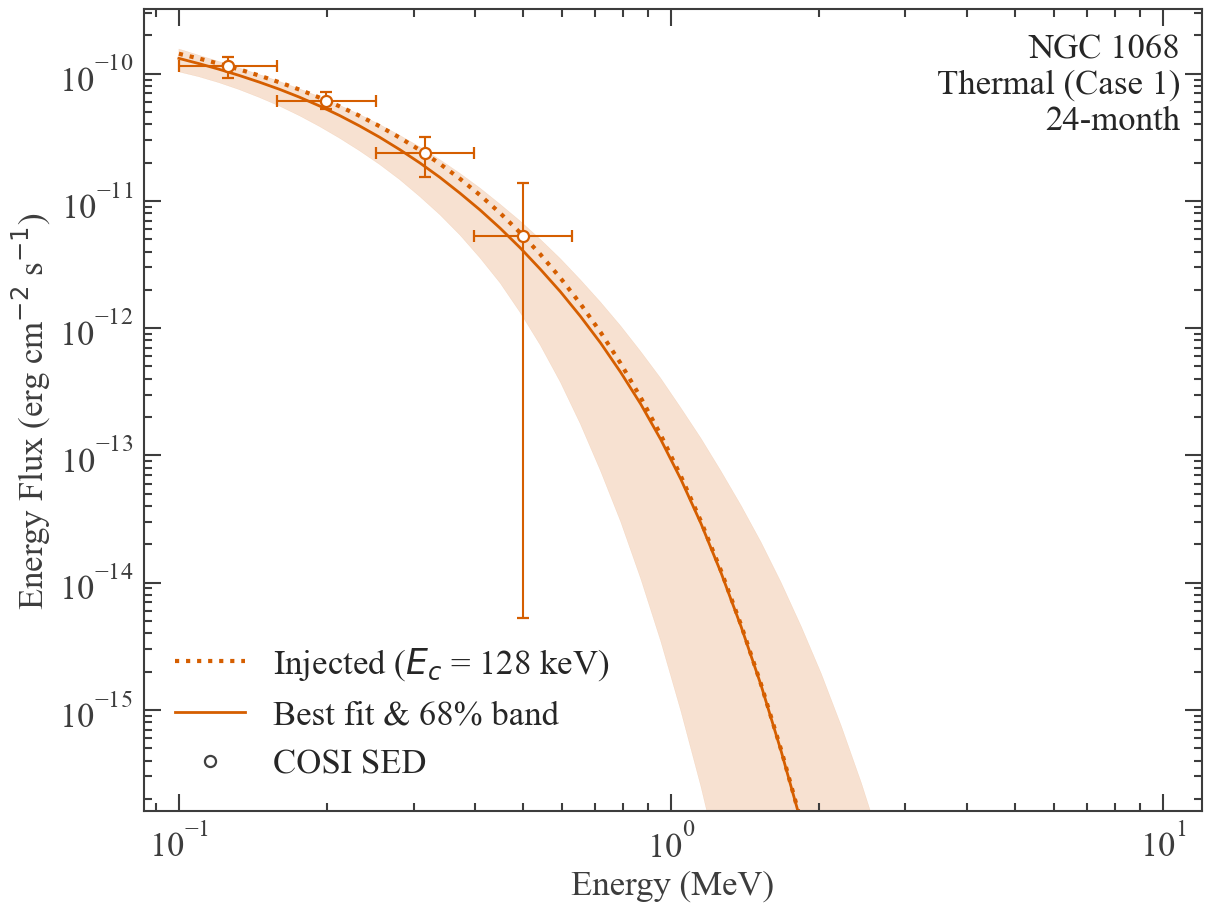

In [32]:
FONT_SIZE = 25

plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})


def _make_xerr(dataframe):
    return KEV_TO_MEV * np.vstack([
        dataframe["e_ref_keV"] - dataframe["e_min_keV"],
        dataframe["e_max_keV"] - dataframe["e_ref_keV"],
    ])


def _split_sed_detections(dataframe, ts_threshold=4.0, min_plot_ts=1.0):
    plot_mask = np.ones(len(dataframe), dtype=bool)
    upper_limit_mask = dataframe['is_upper_limit'].copy()
    if 'ts_value' in dataframe.columns:
        plot_mask = dataframe['ts_value'] >= min_plot_ts
        upper_limit_mask = upper_limit_mask | (dataframe['ts_value'] < ts_threshold)
    return (
        dataframe.loc[plot_mask & ~upper_limit_mask].copy(),
        dataframe.loc[plot_mask & upper_limit_mask].copy(),
    )


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top=True, pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top=True, pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right=True, pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right=True, pad=8)
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

color = '#D55E00'
facecolor = 'white'
detections, upper_limits = _split_sed_detections(thermal_cosi_sed_df)

ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy**2 * flux_inj,
    color=color,
    ls=':',
    lw=3,
    label=fr'Injected thermal model ($E_c$ = {cutoff_keV} keV)',
)
ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy**2 * flux_median,
    color=color,
    lw=2,
    label='Global COSI-only fit',
)
ax.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy**2 * flux_lo,
    SED_KEV_TO_ERG * energy**2 * flux_hi,
    alpha=0.18,
    color=color,
)

if not detections.empty:
    detection_yerr = np.vstack([
        np.maximum(detections['sed_erg_cm2_s'] - detections['sed_lo_erg_cm2_s'], 0),
        np.maximum(detections['sed_hi_erg_cm2_s'] - detections['sed_erg_cm2_s'], 0),
    ])
    ax.errorbar(
        detections['e_ref_keV'] * KEV_TO_MEV,
        detections['sed_erg_cm2_s'],
        xerr=_make_xerr(detections),
        yerr=detection_yerr,
        fmt='o',
        color=color,
        ecolor=color,
        markerfacecolor=facecolor,
        markeredgecolor=color,
        markeredgewidth=1.6,
        elinewidth=1.5,
        capsize=4,
        markersize=8,
        label='_nolegend_',
    )

if not upper_limits.empty:
    upper_y = upper_limits['sed_hi_erg_cm2_s'].to_numpy()
    ax.errorbar(
        upper_limits['e_ref_keV'] * KEV_TO_MEV,
        upper_y,
        xerr=_make_xerr(upper_limits),
        yerr=np.maximum(0.5 * upper_y, np.finfo(float).tiny),
        uplims=True,
        fmt='v',
        color=color,
        ecolor=color,
        markerfacecolor=facecolor,
        markeredgecolor=color,
        markeredgewidth=1.8,
        elinewidth=2.4,
        capsize=6,
        markersize=11,
        barsabove=True,
        zorder=6,
        label='_nolegend_',
    )

legend_handles = [
    plt.Line2D([], [], color=color, ls=':', lw=3, label=fr'Injected ($E_c$ = {cutoff_keV} keV)'),
    plt.Line2D([], [], color=color, lw=2, label='Best fit & 68% band'),
]
if not detections.empty or not upper_limits.empty:
    legend_handles.append(
        plt.Line2D([], [], color='0.25', marker='o', markerfacecolor='white', markeredgewidth=1.6, linestyle='None', markersize=8, label='COSI SED')
    )

ax.text(
    0.98,
    0.97,
    f'NGC 1068\nThermal (Case 1)\n{exposure_1068}-month',
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=FONT_SIZE,
    fontweight='550',
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim((85) * KEV_TO_MEV, (12000) * KEV_TO_MEV)
ax.set_ylim(1e-7 * SED_KEV_TO_ERG, 2e-1 * SED_KEV_TO_ERG)
# ax.xaxis.set_major_locator(mticker.FixedLocator([0.1, 5, 10]))
# ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.1", "5", "10"]))
ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
ax.set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
ax.legend(handles=legend_handles, fontsize=FONT_SIZE, loc='lower left', frameon=False)

save_path = (
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    f"Papers/AGN_Corona_EC_Overleaf/Plots/NGC1068_ThModel_TH_{cutoff_keV}_{exposure_1068}Months_COSI_SED.pdf"
)
plt.savefig(save_path)
